#Load and clean Dataset

In [1]:
import pandas as pd

# Load your dataset
df = pd.read_csv('/final_test1.csv')

# Strip any spaces in column names
df.columns = df.columns.str.strip()

# 1. Drop non-useful columns (identifier columns or heavy text fields)
columns_to_drop = [
    'ts', 'uid', 'id.orig_h', 'id.resp_h',
    'history', 'local_orig', 'local_resp',
    'tunnel_parents', 'detailed-label'
]
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

# 2. Encode the 'proto' column manually
df['proto'] = df['proto'].map({'tcp': 0, 'udp': 1, 'icmp': 2})  # add more protocols if needed

# 3. Encode the 'label' column
df['label'] = df['label'].map({'Benign': 0, 'Malicious': 1})

# 4. Drop any remaining columns that are still non-numeric
for col in df.columns:
    if df[col].dtype == 'object':
        df.drop(columns=[col], inplace=True)

# 5. Fill missing values if any (- or empty cells) with 0
df.fillna(0, inplace=True)

# 6. Now your dataframe is fully numeric and ready for MinMaxScaler or ML models
print(df.head())
print("Final shape:", df.shape)


   id.orig_p  id.resp_p  proto  missed_bytes  orig_pkts  orig_ip_bytes  \
0      53854         23      0             0          1             60   
1      36495       9527      0             0          1             60   
2      56144       9527      0             0          2            120   
3      43763      41534      1             0          1             40   
4      40038       2323      0             0          1             60   

   resp_pkts  resp_ip_bytes  label  
0          0              0      1  
1          0              0      1  
2          0              0      1  
3          0              0      0  
4          0              0      1  
Final shape: (100000, 9)


#Train-Test Split and Label Separation

In [2]:
X = df.drop(columns=['label'])
y = df['label']


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Normalize the data
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Model Training – Machine Learning (Random Forest and SVM)

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

# Random Forest
rf = RandomForestClassifier(n_estimators=52, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# SVM
#svm = SVC(kernel='rbf', probability=True)
#svm.fit(X_train, y_train)
#svm_preds = svm.predict(X_test)

# Evaluation
print("\n--- Random Forest ---")
print(classification_report(y_test, rf_preds))
print("\n--- SVM ---")
print(classification_report(y_test, svm_preds))



--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14008
           1       1.00      1.00      1.00     15992

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000


--- SVM ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     14008
           1       0.98      1.00      0.99     15992

    accuracy                           0.99     30000
   macro avg       0.99      0.99      0.99     30000
weighted avg       0.99      0.99      0.99     30000



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:50:55] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



--- XGBoost Classifier ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14008
           1       1.00      1.00      1.00     15992

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000

Accuracy: 0.9997


# 7. Deep Learning – CNN and LSTM - Data preprocessing

In [7]:
from tensorflow.keras.utils import to_categorical

# Normalize (already done)
X_dl = X  # already scaled

# Reshape to 3D (samples, timesteps=features, channels=1)
X_dl = X_dl.reshape((X_dl.shape[0], X_dl.shape[1], 1))

# One-hot encode labels
y_dl = to_categorical(y)


#CNN Model

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

cnn = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_dl.shape[1], 1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.fit(X_dl, y_dl, epochs=6, batch_size=32, validation_split=0.2)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/6
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9819 - loss: 0.1031 - val_accuracy: 0.9924 - val_loss: 0.0360
Epoch 2/6
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9914 - loss: 0.0434 - val_accuracy: 0.9920 - val_loss: 0.0373
Epoch 3/6
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9914 - loss: 0.0435 - val_accuracy: 0.9933 - val_loss: 0.0358
Epoch 4/6
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9926 - loss: 0.0390 - val_accuracy: 0.9938 - val_loss: 0.0341
Epoch 5/6
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9921 - loss: 0.0414 - val_accuracy: 0.9934 - val_loss: 0.0340
Epoch 6/6
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9924 - loss: 0.0395 - val_accuracy: 0.9935 - val_loss: 0.0331


#LSTM Model

In [9]:
from tensorflow.keras.layers import LSTM

lstm = Sequential([
    LSTM(64, input_shape=(X_dl.shape[1], 1)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm.fit(X_dl, y_dl, epochs=6, batch_size=32, validation_split=0.2)


Epoch 1/6


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9574 - loss: 0.1547 - val_accuracy: 0.9880 - val_loss: 0.0513
Epoch 2/6
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - accuracy: 0.9876 - loss: 0.0544 - val_accuracy: 0.9883 - val_loss: 0.0468
Epoch 3/6
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - accuracy: 0.9883 - loss: 0.0516 - val_accuracy: 0.9918 - val_loss: 0.0424
Epoch 4/6
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9892 - loss: 0.0510 - val_accuracy: 0.9884 - val_loss: 0.0542
Epoch 5/6
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9896 - loss: 0.0492 - val_accuracy: 0.9902 - val_loss: 0.0436
Epoch 6/6
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9913 - loss: 0.0436 - val_accuracy: 0.9909 - val_loss: 0.0408


#Accuracy comparison

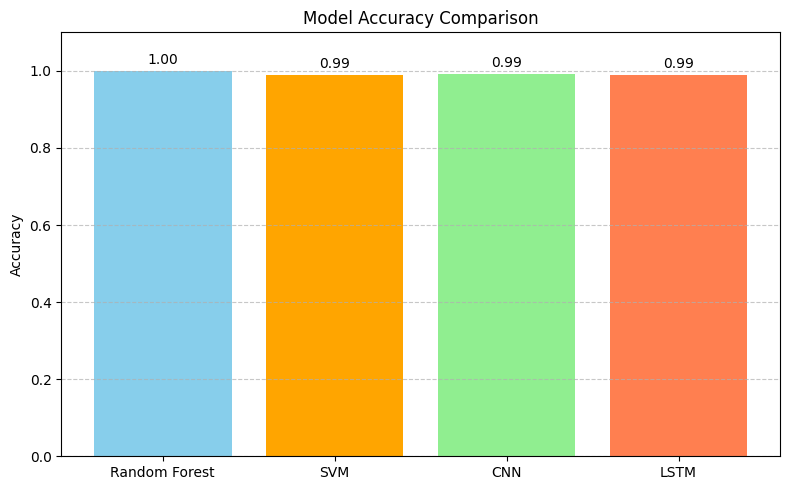

In [12]:
#import all the Metrics
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_recall_curve, roc_curve, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Get model accuracies
rf_acc = rf.score(X_test, y_test)
svm_acc = svm.score(X_test, y_test)
cnn_loss, cnn_acc = cnn.evaluate(X_dl, y_dl, verbose=0)
lstm_loss, lstm_acc = lstm.evaluate(X_dl, y_dl, verbose=0)


model_names = ['Random Forest', 'SVM', 'CNN', 'LSTM']
accuracies = [rf_acc, svm_acc, cnn_acc, lstm_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=['skyblue', 'orange', 'lightgreen', 'coral'])
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#Visualization method

In [17]:
def evaluate_model(y_true, y_pred, y_prob, model_name="Model"):
    print(f"--- {model_name} Evaluation ---")

    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}")

    # Precision and Recall
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

    # ROC AUC
    auc = roc_auc_score(y_true, y_prob)
    print(f"ROC AUC: {auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
    plt.plot(recall_vals, precision_vals, marker='.', label=f'{model_name}')
    plt.title(f"{model_name} Precision-Recall Curve")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, marker='.', label=f'{model_name}')
    plt.plot([0,1], [0,1], linestyle='--')  # Diagonal line
    plt.title(f"{model_name} ROC Curve")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.show()


#Visualization for Random Forest

--- Random Forest Evaluation ---
Accuracy: 0.9996
Precision: 0.9992
Recall: 1.0000
ROC AUC: 1.0000


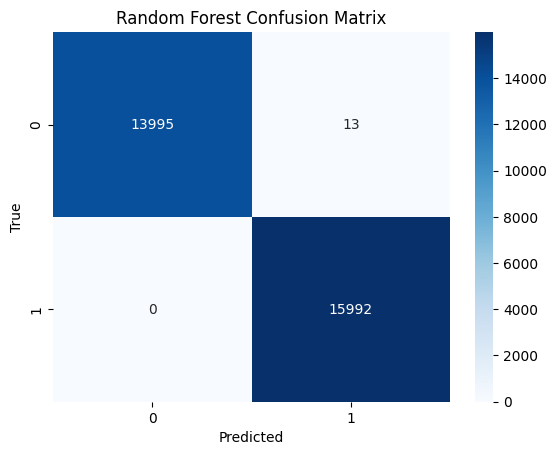

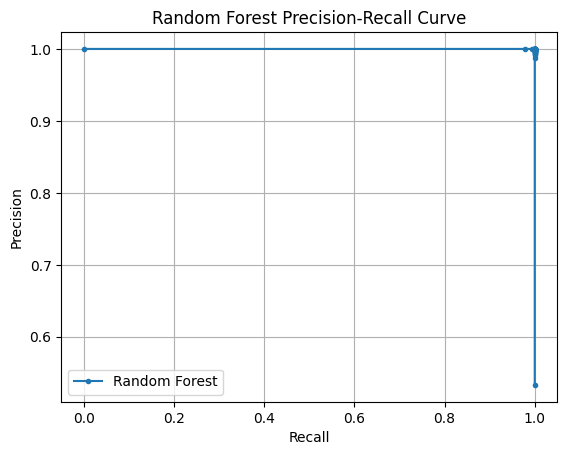

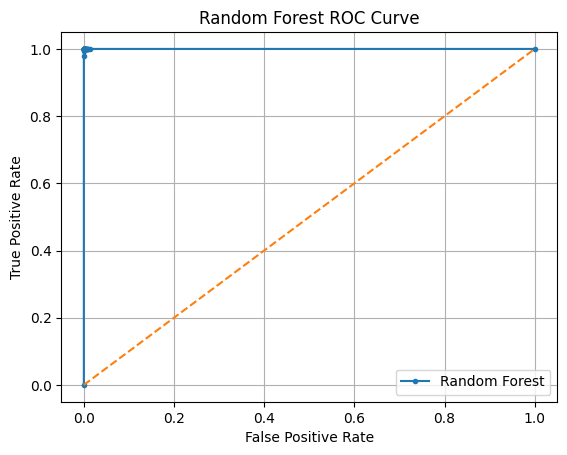

In [21]:
rf_probs = rf.predict_proba(X_test)[:, 1]  # Probability for positive class (malicious)
evaluate_model(y_test, rf_preds, rf_probs, model_name="Random Forest")


#Visualization for SVM

--- SVM Evaluation ---
Accuracy: 0.9899
Precision: 0.9814
Recall: 1.0000
ROC AUC: 0.9898


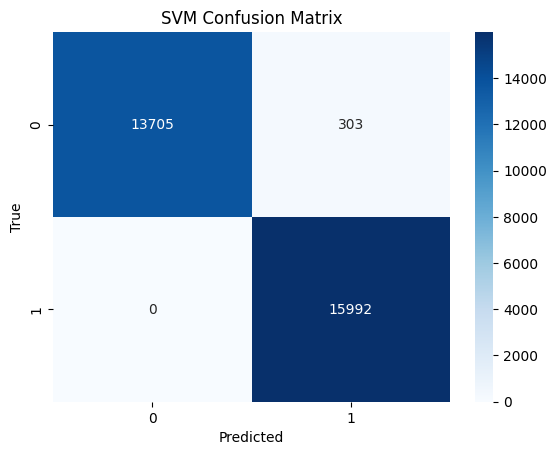

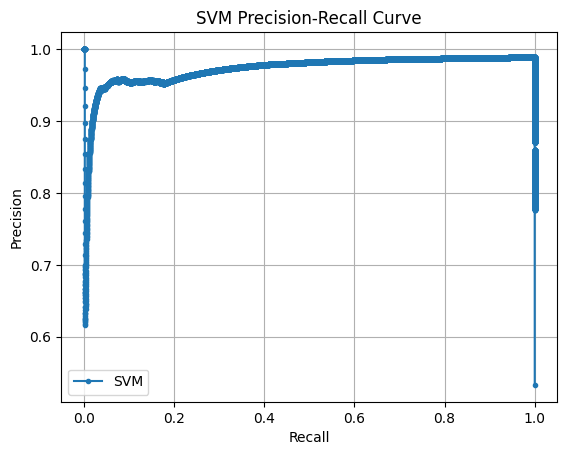

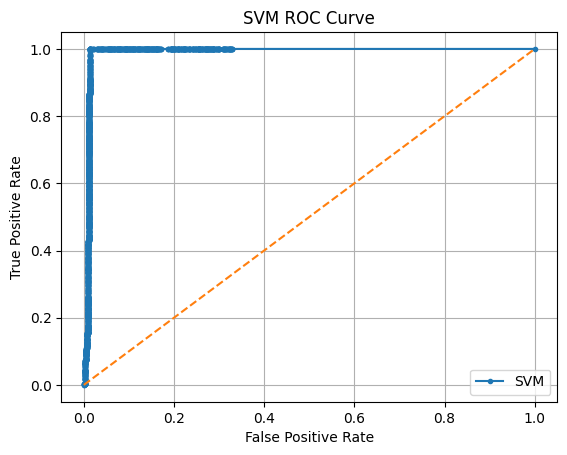

In [20]:
svm_probs = svm.predict_proba(X_test)[:, 1]  # SVM also returns probabilities
evaluate_model(y_test, svm_preds, svm_probs, model_name="SVM")


#Visualization for CNN

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
--- CNN Evaluation ---
Accuracy: 0.9924
Precision: 0.9861
Recall: 0.9999
ROC AUC: 0.9962


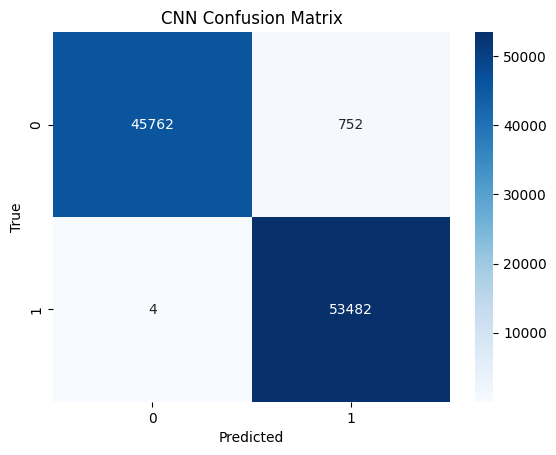

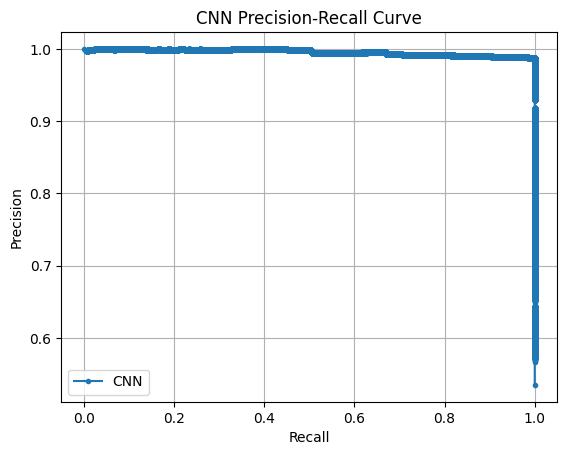

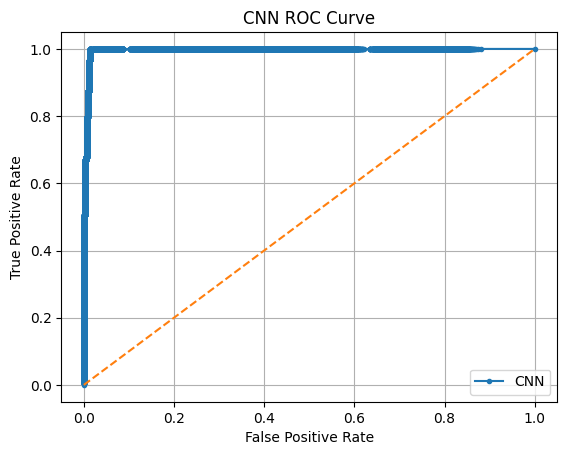

In [19]:
cnn_preds_prob = cnn.predict(X_dl)
cnn_preds_class = cnn_preds_prob.argmax(axis=1)
evaluate_model(y, cnn_preds_class, cnn_preds_prob[:,1], model_name="CNN")


#Visualization for LSTM

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
--- LSTM Evaluation ---
Accuracy: 0.9903
Precision: 0.9823
Recall: 0.9999
ROC AUC: 0.9950


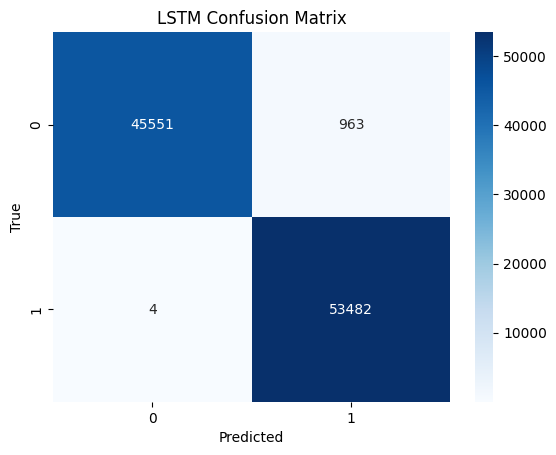

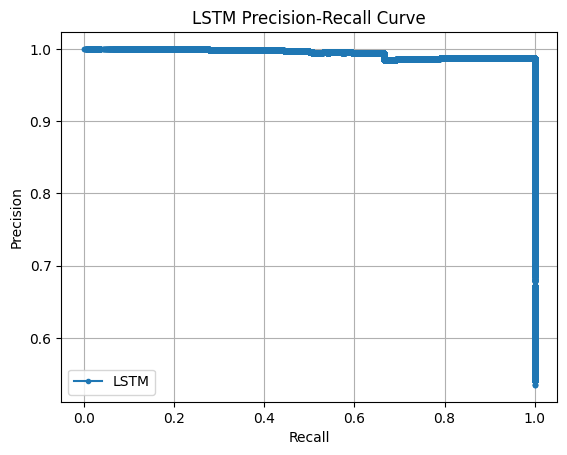

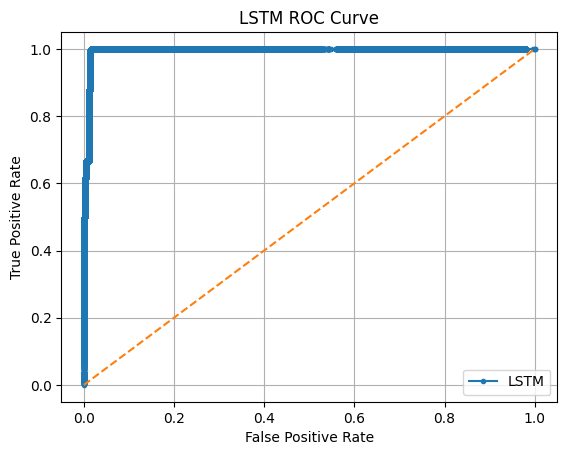

In [18]:
lstm_preds_prob = lstm.predict(X_dl)
lstm_preds_class = lstm_preds_prob.argmax(axis=1)
evaluate_model(y_true=y, y_pred=lstm_preds_class, y_prob=lstm_preds_prob[:,1], model_name="LSTM")


In [ ]:
df.corr()['label'].sort_values(ascending=False)


,label
label,1.000000
orig_ip_bytes,0.319042
id.orig_p,0.276459
orig_pkts,0.224768
resp_pkts,0.062958
resp_ip_bytes,0.060755
id.resp_p,-0.704640
proto,-0.889095
missed_bytes,NaN


In [25]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(RandomForestClassifier(), X, y, cv=5)
print("Mean Cross-Validation Accuracy:", scores.mean())


Mean Cross-Validation Accuracy: 0.9995499999999999
